In [1]:
import numpy as np
import pandas as pd
import scipy
import copy

import random

from src.simulation.domain.model import construct_well, h_lim, betta_G_lim
from src.simulation.service_layer.services import get_dict_for_data, build_plot, PlotData, Scale
from src.simulation.domain.meter import Meter, add_noise
from src.identification.domain.model import ident_values, identificate, get_data_by_slices, identificate_regul, get_res_dict_for_ident
from src.identification.service_layer.services import calc_rsd_by_series, calc_bias_by_series, calc_error
from src.identification.service_layer.services import calc_rsd_by_series, calc_bias_by_series, calc_error, calc_error_by_series

In [2]:
# Начальные условия
M_q = 0.5
epsilon = 0.00001
K_NUMBERS = 45000  # Количество точек моделирования
dt = 0.0001  # Суток

w_program = {2: 1.065556, 3: 0.9335, 3.7: 1}

well = construct_well(agzu_on=False, p_L_change_on=False)
well.set_w_program(w_program)


df = well.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
df = pd.DataFrame(df)

In [3]:
df = df.iloc[10000:].reset_index(drop=True)

In [4]:
#df.to_csv(
#    'model_output.csv',
#    sep=';',            # разделитель ; если открываете в Excel (RU)
#    decimal=',',
#)

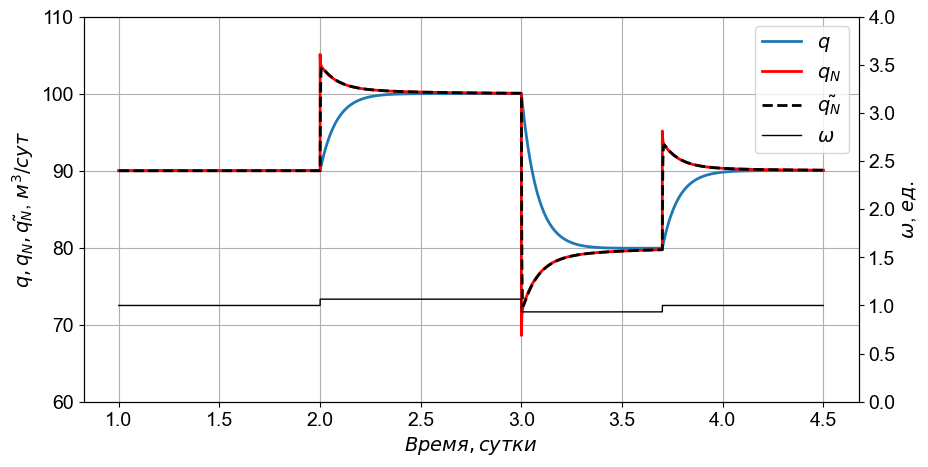

In [5]:
plot_data = [
             {'data': (
                PlotData(df['q'], '', 2, 'q'),
                PlotData(df['q_N'], 'r', 2, 'q_N'),
                PlotData(df['q_L'], 'k--', 2, '\\tilde{q_N}'),
              ), 'x': df['x'], 'y_scale': Scale(min=60, max=110), 'dt': dt, 'mu': 'м^3/сут'},
             {'data': (
               PlotData(df['u'], 'k', 1, '\omega'),
               #PlotData(df['agzu'], 'g', 1, 'АГЗУ'),
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=4), 'dt': dt, 'mu': 'ед.'},
            ]

plot = build_plot(plot_data)
plot.show()

In [6]:
#df.to_excel("model_output.xlsx")

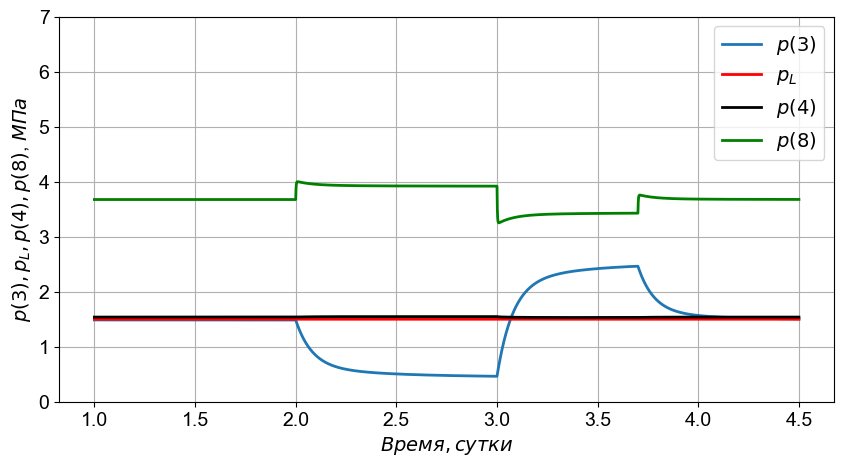

In [7]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_4'], 'k', 2, 'p(4)'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=7), 'dt': dt, 'mu': 'МПа'},

]


plot = build_plot(plot_data)
plot.show()

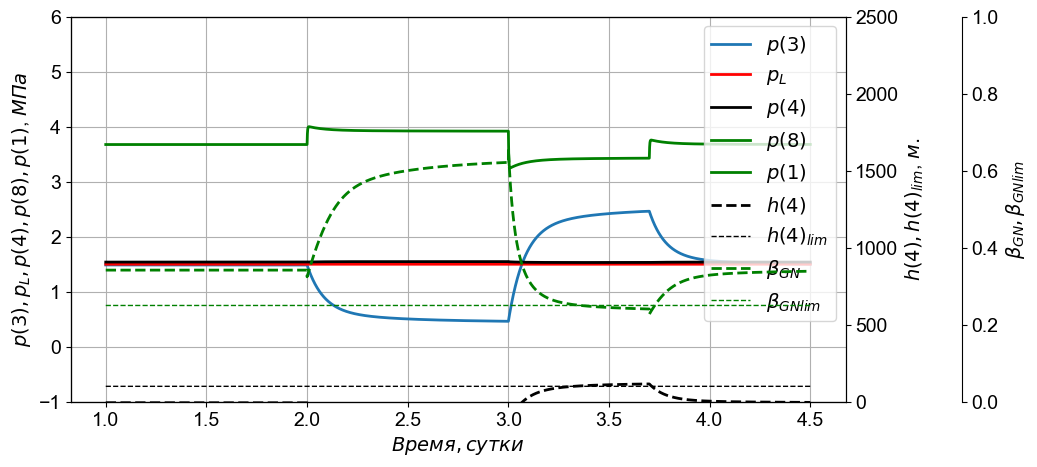

In [8]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_4'], 'k', 2, 'p(4)'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              PlotData(df['p_1'], 'g', 2, 'p(1)'),
              ), 'x': df['x'], 'y_scale': Scale(min=-1, max=6), 'dt': dt, 'mu': 'МПа'},
            {'data': (
                PlotData(df['h_4'], 'k--', 2, 'h(4)'),
                PlotData(pd.Series([h_lim]*K_NUMBERS), 'k--', 1, 'h(4)_{lim}')
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=2500), 'dt': dt, 'mu': 'м.'},
            {'data': (
                PlotData(df['betta_GN'], 'g--', 2, '\\beta_{GN}'),
                PlotData(pd.Series([betta_G_lim]*K_NUMBERS), 'g--', 1, '\\beta_{GNlim}')
              ), 'x': df['x'], 'y_scale':  Scale(min=0, max=1), 'dt': dt},
]


plot = build_plot(plot_data)
plot.show()

In [9]:
meter = Meter(dt)
meter.noise_enable = True
meter.noise_amplitude = 0.03
ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator = 20)

In [10]:
#df_ident.to_excel("model_measure.xlsx")

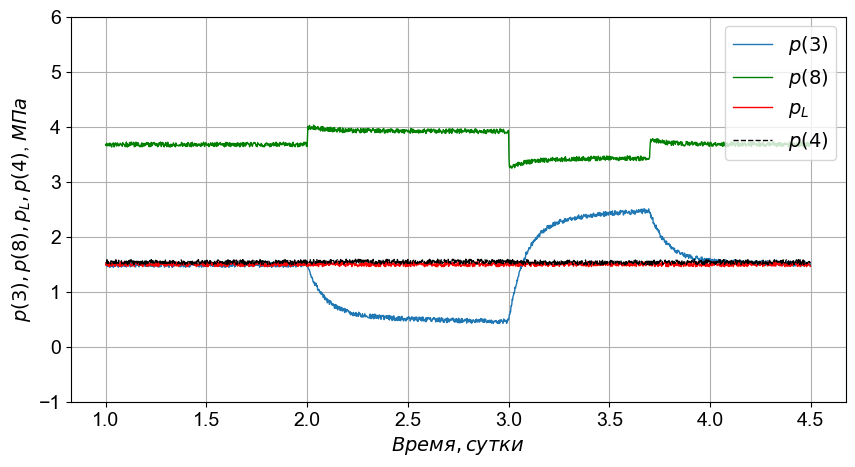

In [11]:
plot_data = [
            {'data': (
              PlotData(df_ident['p_3'], '', 1, 'p(3)'),
              PlotData(df_ident['p_8'], 'g', 1, 'p(8)'),
              PlotData(df_ident['p_L'], 'r', 1, 'p_L'),
              PlotData(df_ident['p_4'], 'k--', 1, 'p(4)'),
              ), 'x': df_ident['x'], 'y_scale': Scale(min=-1, max=6), 'dt': dt, 'mu': 'МПа'},
            ]

plot = build_plot(plot_data)
plot.show()

In [12]:
# Иерархичная идентификация

experiment_num_max = 5

#t_N_experiment = np.linspace(0.5*well.pump.t_N, 1.5*well.pump.t_N, experiment_num_max)
#t_N_experiment.sort()
#
#t_N_experiment = np.array(t_N_experiment)
#
#t_N_calc = []
#t_N_experiments_calc = []
#r_N_calc = []

T_experiment = np.linspace(0.4*well.reservoir.T_2, 2*well.reservoir.T_2, experiment_num_max)
T_experiment.sort()

T_experiment = np.array(T_experiment)

T_R_calc = []
T_R_experiments_calc = []

p_R_calc = []
r_1_calc = []
r_2_calc = []

meter = Meter(dt)
meter.noise_enable = False
meter.noise_amplitude = 0

damping = 0.7
tol_t = 1e-4          # порог для t_N
t_N_best = None         # лучшее t_N с прошлой итерации
T_R_best = None

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

for epoch in range(50):
    J = []
    res = {
    'p_R': np.zeros(experiment_num_max),
    'r_1': np.zeros(experiment_num_max),
    'r_2': np.zeros(experiment_num_max),
}

    for experiment_num in range(experiment_num_max):

      well.reservoir.T_2 = float(T_experiment[experiment_num])
      #well.pump.t_N = float(t_N_experiment[experiment_num])

      calc_df = ident_values(ident_k, ident_dt, df_ident, well, filter_name=None)

      b, squared_error_sum = identificate(calc_df, ident_k)

      res['p_R'][experiment_num] = b[0]
      res['r_1'][experiment_num] = b[1]
      res['r_2'][experiment_num] = b[2]

      J.append(squared_error_sum)

    #X = np.array([[1]*experiment_num_max,
    #              T_experiment,
    #              t_N_experiment,
    #              T_experiment**2,
    #              2*T_experiment*t_N_experiment,
    #              t_N_experiment**2
    #             ]).T
    X = np.array([[1]*experiment_num_max,
              T_experiment,
              -(0.5 * T_experiment**2),
             ]).T

    y = np.array(J).T
    a, squared_error_sum, matrix_rank, SVD_ = scipy.linalg.lstsq(X, y)


    #X1 = np.array([
    #    [2*a[3], 2*a[4]],
    #    [2*a[4], 2*a[5]]
    #])
#
    #Y1 = np.array([
    #    [-a[1]],
    #    [-a[2]]
    #])
#
    #times = np.linalg.inv(X1).dot(Y1)
    #T_R = times[0][0]
    #t_N = times[1][0]

    T_R = a[1]/(a[2])

    best_i = np.argmin(J)
    if epoch == 0:
        T_R_experiments_calc.append(copy.deepcopy(T_experiment))
        #t_N_experiments_calc.append(copy.deepcopy(t_N_experiment))



        T_R_calc.append(T_experiment[best_i])
        #t_N_calc.append(t_N_experiment[best_i])

    p_R_calc.append(res['p_R'][best_i])
    r_1_calc.append(res['r_1'][best_i])
    r_2_calc.append(res['r_2'][best_i])

    if T_R_best is not None and abs(T_R - T_R_best) <= tol_t:
        break
    T_R_best = T_R

    i = np.argmax(J)

    T_experiment[i] = (1 - damping) * T_experiment[i] + damping * T_R
    T_experiment.sort()

    T_R_experiments_calc.append(copy.deepcopy(T_experiment))
    T_R_calc.append(T_R)

    #if t_N_best is not None and abs(t_N - t_N_best) <= tol_t:
    #    break
    #t_N_best = t_N
#
    #new = (1 - damping) * t_N_experiment[i] + damping * t_N
    #t_N_experiment[i] = new
    #t_N_experiment.sort()
#
    #t_N_experiments_calc.append(copy.deepcopy(t_N_experiment))
    #t_N_calc.append(t_N)

    #well.reservoir.T_2 = T_R_best
    #well.pump.t_N = t_N_best
    #calc_df = ident_values(ident_k, ident_dt, df_ident, well, filter_name=None)
#
    #b, squared_error_sum = identificate(calc_df, ident_k)
#
    #p_R_calc.append(b[0])
    #r_1_calc.append(b[1])
    #r_2_calc.append(b[2])


In [13]:
#well.pump.t_N = 0.02
#x_len = len(t_N_calc)
#df = pd.DataFrame({'pots': t_N_experiments_calc, 't_N': t_N_calc, 'x': list(range(x_len)),
#                   't_N_model': [well.pump.t_N] * x_len})

In [14]:
#import matplotlib.pyplot as plt
#import numpy as np
#epochs = np.arange(len(t_N_experiments_calc))
#t_min = np.array([g.min() for g in t_N_experiments_calc])
#t_max = np.array([g.max() for g in t_N_experiments_calc])
#fig, ax = plt.subplots(figsize=(9, 5))
## сужающийся диапазон
#ax.fill_between(epochs, t_min, t_max, alpha=0.25, color='tab:blue', label='диапазон сетки $[t_{min}, t_{max}]$')
## все пробные точки
#for k, grid in enumerate(t_N_experiments_calc):
#    ax.scatter(np.full(len(grid), k), grid, s=25, alpha=0.6, color='tab:blue', zorder=3)
## минимум параболы / лучшая оценка t_N
#ax.plot(epochs, df['t_N'].values[:len(epochs)], 'r', lw=1.5, label=r'$\hat t_N$')
## истинное значение
#ax.axhline(well.pump.t_N, ls='--', color='k', label=r'$t_N$ (модель)')
#ax.set_xlabel('Номер итерации')
#ax.set_ylabel(r'$t_N$, сут')
#ax.legend()
#ax.grid(True, alpha=0.3)
#plt.tight_layout()
#plt.show()

In [15]:
T_R_calc

[np.float64(0.48000000000000004),
 np.float64(0.526734719037952),
 np.float64(0.38582711175346396),
 np.float64(0.4136586421921539),
 np.float64(0.41060493981065804),
 np.float64(0.4088510430665464),
 np.float64(0.3960929425461369),
 np.float64(0.39641623195465203),
 np.float64(0.3978437901793241),
 np.float64(0.3981209639640278)]

In [16]:
well.reservoir.T_2 = 0.4
x_len = len(T_R_calc)
df = pd.DataFrame({'pots': T_R_experiments_calc, 'T_R': T_R_calc,
                   'x': list(range(x_len)),
                   'T_R_model': [well.reservoir.T_2]* x_len,
                   })

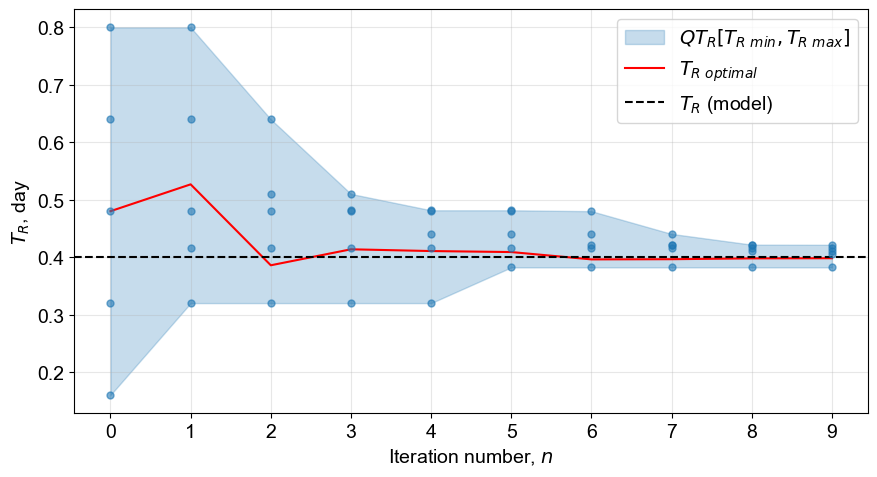

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
epochs = np.arange(len(T_R_experiments_calc))
t_min = np.array([g.min() for g in T_R_experiments_calc])
t_max = np.array([g.max() for g in T_R_experiments_calc])
fig, ax = plt.subplots(figsize=(9, 5))
# сужающийся диапазон
ax.fill_between(epochs, t_min, t_max, alpha=0.25, color='tab:blue', label='$QT_R [T_{R\ min}, T_{R\ max}]$')
# все пробные точки
for k, grid in enumerate(T_R_experiments_calc):
    ax.scatter(np.full(len(grid), k), grid, s=25, alpha=0.6, color='tab:blue', zorder=3)
# минимум параболы / лучшая оценка t_N
ax.plot(epochs, df['T_R'].values[:len(epochs)], 'r', lw=1.5, label=r'$T_{R\ optimal}$')
# истинное значение
ax.axhline(well.reservoir.T_2, ls='--', color='k', label=r'$T_R$ (model)')
ax.set_xlabel('Iteration number, $n$')
ax.set_ylabel(r'$T_R$, day')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

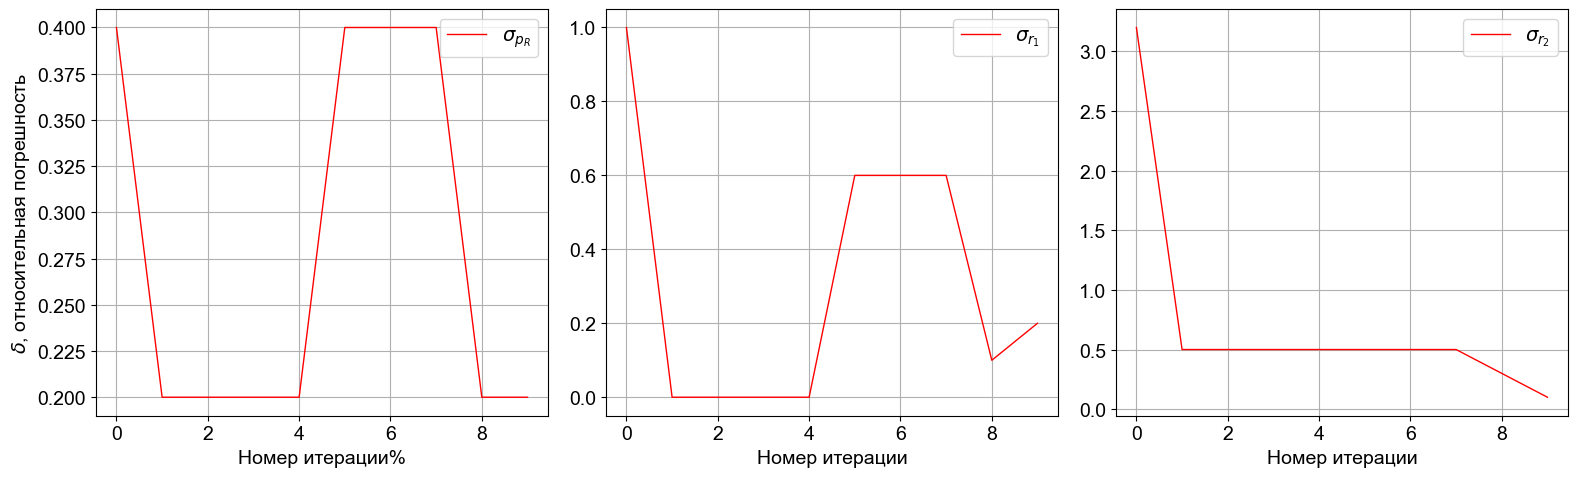

In [18]:
from matplotlib import pyplot as plt

# Визуализация
plt.figure(figsize=(16, 5))

# График давления
plt.subplot(1, 3, 1)
plt.plot(epochs, [calc_error(np.array([p_R]), well.reservoir.p_R) for p_R in p_R_calc], 'r', lw=1, label='$\sigma_{p_R}$')

plt.xlabel('Номер итерации%')
plt.ylabel('$\delta$, относительная погрешность')
plt.legend()
plt.grid()


# График НЧ шума
plt.subplot(1, 3, 2)
plt.plot(epochs, [calc_error(np.array([r_1]), well.reservoir.r_1) for r_1 in r_1_calc], 'r',  label='$\sigma_{r_1}$', lw=1)

plt.xlabel('Номер итерации')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)

# График ВЧ шума
plt.subplot(1, 3, 3)
plt.plot(epochs, [calc_error(np.array([r_2]), well.reservoir.r_2) for r_2 in r_2_calc], 'r', label='$\sigma_{r_2}$', lw=1)
plt.xlabel('Номер итерации')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)


plt.tight_layout()
plt.show()

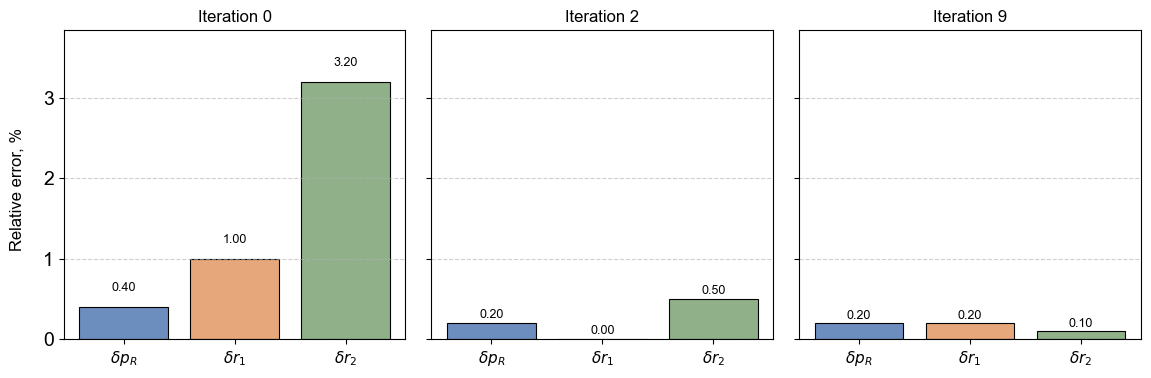

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Ваши данные (замените на реальные вычисления)
values1 = [calc_error(np.array([p_R_calc[0]]), well.reservoir.p_R),
           calc_error(np.array([r_1_calc[0]]), well.reservoir.r_1),
           calc_error(np.array([r_2_calc[0]]), well.reservoir.r_2)]

values2 = [calc_error(np.array([p_R_calc[2]]), well.reservoir.p_R),
           calc_error(np.array([r_1_calc[2]]), well.reservoir.r_1),
           calc_error(np.array([r_2_calc[2]]), well.reservoir.r_2)]

values3 = [calc_error(np.array([p_R_calc[-1]]), well.reservoir.p_R),
           calc_error(np.array([r_1_calc[-1]]), well.reservoir.r_1),
           calc_error(np.array([r_2_calc[-1]]), well.reservoir.r_2)]

labels = ['$\delta{p_R}$', '$\delta{r_1}$', '$\delta{r_2}$']

# Настройка фигуры: три подграфика в ряд
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# Данные для каждого графика и заголовки
data_sets = [values1, values2, values3]
titles = ['Iteration 0', 'Iteration 2', 'Iteration 9']

# Цвета для столбцов (можно изменить)
colors = ['#6c8ebf', '#e6a87b', '#8fb088']

# Построение
for ax, data, title in zip(axes, data_sets, titles):
    x = np.arange(len(labels))
    bars = ax.bar(x, data, color=colors, edgecolor='black', linewidth=0.8)

    # Подписи значений над столбцами
    for bar, val in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width()/2., val + 0.05*max(data),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    # Оформление
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim(0, max(max(data_sets)) * 1.2)  # автоматический отступ сверху

# Общая подпись для оси Y (слева)
fig.text(0.04, 0.5, 'Relative error, %', va='center', rotation='vertical', fontsize=12)

# Корректировка отступов и отображение
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()